AMBIENTE
Plataforma  : Windows-11-10.0.26200-SP0
Arquitetura : ARM64   (esperado ARM64 no Snapdragon X Elite)
Processador : ARMv8 (64-bit) Family 8 Model 1 Revision 201, Qualcomm Technologies Inc
Python      : 3.13.9
NumPy       : 2.3.5
Pandas      : 2.3.3
Dask        : unknown

N =      100,000  (    0.8 MB, 1 particoes) ... pandas     0.34 ms | dask     7.19 ms
N =      300,000  (    2.4 MB, 1 particoes) ... pandas     0.71 ms | dask    11.01 ms
N =    1,000,000  (    8.0 MB, 1 particoes) ... pandas     2.71 ms | dask    11.10 ms
N =    3,000,000  (   24.0 MB, 1 particoes) ... pandas     9.68 ms | dask    19.22 ms
N =   10,000,000  (   80.0 MB, 1 particoes) ... pandas    32.59 ms | dask    42.34 ms
N =   30,000,000  (  240.0 MB, 2 particoes) ... pandas   117.10 ms | dask    70.77 ms
N =   50,000,000  (  400.0 MB, 3 particoes) ... pandas   145.59 ms | dask    84.09 ms
N =   70,000,000  (  560.0 MB, 4 particoes) ... pandas   184.75 ms | dask    97.09 ms
N =  100,000,000  (  800.0 MB, 6

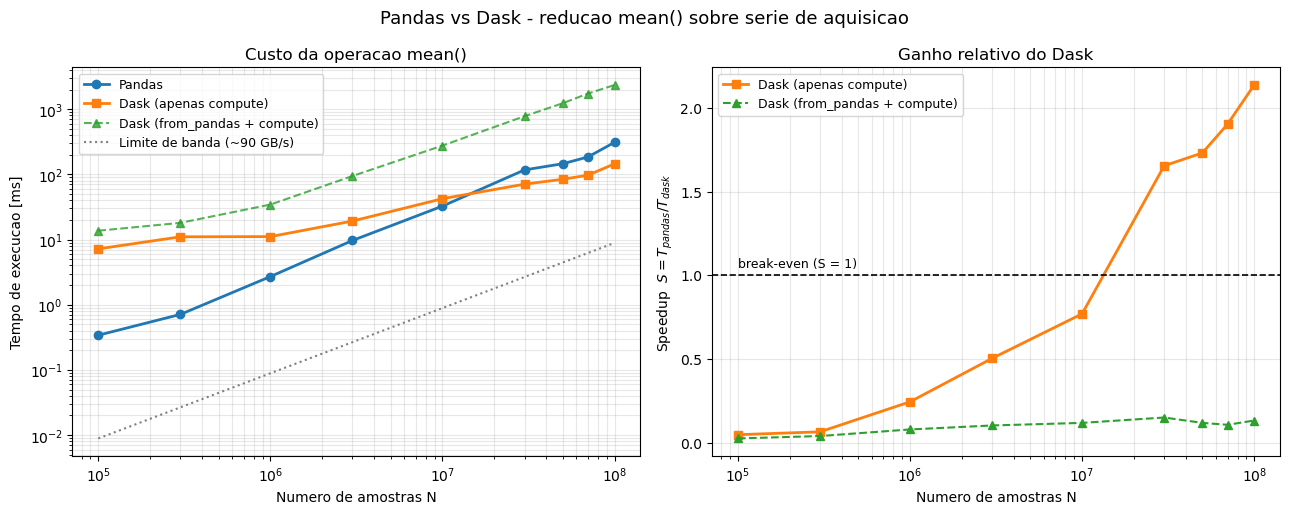

In [3]:
"""
Benchmark: Pandas vs Dask na operacao mean()
=============================================

Objetivo
--------
Medir experimentalmente a partir de qual tamanho de dado o paralelismo do Dask
compensa o custo fixo de construir e escalonar o grafo de tarefas.

Contexto de engenharia
----------------------
O dado sintetico simula uma aquisicao experimental de temperatura: um sinal com
uma tendencia lenta somada a ruido gaussiano do sensor. Calcular a media de uma
serie longa de aquisicao e uma das operacoes mais comuns em pos-processamento
de ensaios (bancada de motores, tunel de vento, ensaios de vibracao).

Aluno: <seu nome>
Disciplina: Computacao de Alto Desempenho em Python
"""

import platform
import time

import dask
import dask.dataframe as dd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ----------------------------------------------------------------------------
# 1. PARAMETROS DO EXPERIMENTO
# ----------------------------------------------------------------------------

# Tamanhos varridos em escala aproximadamente logaritmica.
# 5e7 linhas em float64 = 400 MB. Ajuste o teto conforme a RAM disponivel.
TAMANHOS = [
    100_000,
    300_000,
    1_000_000,
    3_000_000,
    10_000_000,
    30_000_000,
    50_000_000,
    70_000_000,
    100_000_000,
]

REPETICOES = 7        # numero de medicoes validas por ponto
AQUECIMENTOS = 2      # execucoes descartadas (cache frio, import tardio)
BYTES_POR_ELEMENTO = 8  # float64

# Largura de banda de memoria estimada da maquina, em GB/s.
# Serve apenas para tracar o piso teorico no grafico.
# Snapdragon X Elite: pico nominal ~135 GB/s; use ~60-70% como valor efetivo.
BANDA_EFETIVA_GB_S = 90.0


# ----------------------------------------------------------------------------
# 2. FUNCAO GENERICA DE MEDICAO
# ----------------------------------------------------------------------------

def medir_tempo(funcao, repeticoes=REPETICOES, aquecimentos=AQUECIMENTOS):
    """
    Executa 'funcao' varias vezes e devolve estatisticas do tempo de execucao.

    Usa perf_counter (relogio monotonico de alta resolucao) e reporta a MEDIANA,
    que e mais robusta a interferencia do sistema operacional do que a media.
    """
    for _ in range(aquecimentos):
        funcao()

    tempos = []
    for _ in range(repeticoes):
        inicio = time.perf_counter()
        funcao()
        tempos.append(time.perf_counter() - inicio)

    tempos = np.array(tempos)
    return {
        "mediana": float(np.median(tempos)),
        "minimo": float(tempos.min()),
        "desvio": float(tempos.std()),
    }


# ----------------------------------------------------------------------------
# 3. GERACAO DOS DADOS SINTETICOS
# ----------------------------------------------------------------------------

def gerar_dados_sensor(n_amostras, semente=42):
    """
    Gera uma serie de leituras de um sensor de temperatura.

    Modelo: T(t) = T0 + deriva_lenta(t) + ruido_branco
    """
    gerador = np.random.default_rng(semente)

    tempo_s = np.arange(n_amostras, dtype=np.float64)
    deriva_lenta = 5.0 * np.sin(2.0 * np.pi * tempo_s / n_amostras)
    ruido_sensor = gerador.normal(loc=0.0, scale=0.3, size=n_amostras)
    temperatura = 25.0 + deriva_lenta + ruido_sensor

    return pd.DataFrame({"temperatura_C": temperatura})


def escolher_n_particoes(n_amostras, alvo_mb=128):
    """
    Escolhe o numero de particoes do Dask mirando ~128 MB por particao,
    que e a recomendacao pratica da documentacao.

    Particao muito pequena -> overhead de escalonamento domina.
    Particao muito grande  -> pouca oportunidade de paralelismo.
    """
    tamanho_mb = n_amostras * BYTES_POR_ELEMENTO / 1e6
    return max(1, int(round(tamanho_mb / alvo_mb)))


# ----------------------------------------------------------------------------
# 4. VARREDURA PRINCIPAL
# ----------------------------------------------------------------------------

def rodar_benchmark(tamanhos=TAMANHOS):
    """
    Para cada tamanho, mede tres cenarios:
      (a) pandas puro
      (b) dask: apenas o .compute() (DataFrame ja particionado)
      (c) dask: conversao from_pandas + .compute()
    """
    resultados = []

    for n_amostras in tamanhos:
        tamanho_mb = n_amostras * BYTES_POR_ELEMENTO / 1e6
        n_particoes = escolher_n_particoes(n_amostras)

        print(f"N = {n_amostras:>12,}  ({tamanho_mb:7.1f} MB, "
              f"{n_particoes} particoes) ... ", end="", flush=True)

        df_pandas = gerar_dados_sensor(n_amostras)
        df_dask = dd.from_pandas(df_pandas, npartitions=n_particoes)

        # (a) pandas puro
        t_pandas = medir_tempo(
            lambda: df_pandas["temperatura_C"].mean()
        )

        # (b) dask, apenas a execucao do grafo
        t_dask_compute = medir_tempo(
            lambda: df_dask["temperatura_C"].mean().compute()
        )

        # (c) dask, incluindo o custo de particionar o dado
        t_dask_total = medir_tempo(
            lambda: dd.from_pandas(
                df_pandas, npartitions=n_particoes
            )["temperatura_C"].mean().compute(),
            repeticoes=3,      # este cenario e mais caro; menos repeticoes
            aquecimentos=1,
        )

        # Verificacao de corretude: os tres caminhos devem dar o mesmo numero
        media_ref = df_pandas["temperatura_C"].mean()
        media_dask = df_dask["temperatura_C"].mean().compute()
        assert np.isclose(media_ref, media_dask, rtol=1e-10), \
            "Divergencia entre pandas e dask!"

        resultados.append({
            "n_amostras": n_amostras,
            "tamanho_mb": tamanho_mb,
            "n_particoes": n_particoes,
            "t_pandas": t_pandas["mediana"],
            "t_dask_compute": t_dask_compute["mediana"],
            "t_dask_total": t_dask_total["mediana"],
            "desvio_pandas": t_pandas["desvio"],
            "desvio_dask": t_dask_compute["desvio"],
        })

        print(f"pandas {t_pandas['mediana']*1e3:8.2f} ms | "
              f"dask {t_dask_compute['mediana']*1e3:8.2f} ms")

        # Libera memoria antes do proximo tamanho
        del df_pandas, df_dask

    tabela = pd.DataFrame(resultados)
    tabela["speedup"] = tabela["t_pandas"] / tabela["t_dask_compute"]
    tabela["speedup_total"] = tabela["t_pandas"] / tabela["t_dask_total"]
    return tabela


# ----------------------------------------------------------------------------
# 5. GRAFICOS
# ----------------------------------------------------------------------------

def plotar_resultados(tabela, arquivo_saida="benchmark_pandas_dask.png"):
    figura, (eixo_tempo, eixo_speedup) = plt.subplots(1, 2, figsize=(13, 5.2))

    n = tabela["n_amostras"]

    # ---- Painel esquerdo: tempo absoluto (log-log) ----
    eixo_tempo.loglog(n, tabela["t_pandas"] * 1e3,
                      "o-", label="Pandas", linewidth=2)
    eixo_tempo.loglog(n, tabela["t_dask_compute"] * 1e3,
                      "s-", label="Dask (apenas compute)", linewidth=2)
    eixo_tempo.loglog(n, tabela["t_dask_total"] * 1e3,
                      "^--", label="Dask (from_pandas + compute)",
                      linewidth=1.5, alpha=0.8)

    # Piso teorico imposto pela largura de banda de memoria
    tempo_banda_ms = (n * BYTES_POR_ELEMENTO / (BANDA_EFETIVA_GB_S * 1e9)) * 1e3
    eixo_tempo.loglog(n, tempo_banda_ms, ":", color="gray",
                      label=f"Limite de banda (~{BANDA_EFETIVA_GB_S:.0f} GB/s)")

    eixo_tempo.set_xlabel("Numero de amostras N")
    eixo_tempo.set_ylabel("Tempo de execucao [ms]")
    eixo_tempo.set_title("Custo da operacao mean()")
    eixo_tempo.grid(True, which="both", alpha=0.3)
    eixo_tempo.legend(fontsize=9)

    # ---- Painel direito: speedup ----
    eixo_speedup.semilogx(n, tabela["speedup"],
                          "s-", color="tab:orange", linewidth=2,
                          label="Dask (apenas compute)")
    eixo_speedup.semilogx(n, tabela["speedup_total"],
                          "^--", color="tab:green", linewidth=1.5,
                          label="Dask (from_pandas + compute)")
    eixo_speedup.axhline(1.0, color="black", linestyle="--", linewidth=1.2)
    eixo_speedup.text(n.iloc[0], 1.05, "break-even (S = 1)", fontsize=9)

    eixo_speedup.set_xlabel("Numero de amostras N")
    eixo_speedup.set_ylabel("Speedup  $S = T_{pandas} / T_{dask}$")
    eixo_speedup.set_title("Ganho relativo do Dask")
    eixo_speedup.grid(True, which="both", alpha=0.3)
    eixo_speedup.legend(fontsize=9)

    figura.suptitle(
        "Pandas vs Dask - reducao mean() sobre serie de aquisicao",
        fontsize=13
    )
    figura.tight_layout()
    figura.savefig(arquivo_saida, dpi=150)
    print(f"\nGrafico salvo em: {arquivo_saida}")
    plt.show()


# ----------------------------------------------------------------------------
# 6. EXECUCAO
# ----------------------------------------------------------------------------

if __name__ == "__main__":
    print("=" * 70)
    print("AMBIENTE")
    print("=" * 70)
    print(f"Plataforma  : {platform.platform()}")
    print(f"Arquitetura : {platform.machine()}   "
          f"(esperado ARM64 no Snapdragon X Elite)")
    print(f"Processador : {platform.processor()}")
    print(f"Python      : {platform.python_version()}")
    print(f"NumPy       : {np.__version__}")
    print(f"Pandas      : {pd.__version__}")
    print(f"Dask        : {dask.__version__}")
    print()

    tabela_resultados = rodar_benchmark()

    print("\n" + "=" * 70)
    print("RESULTADOS")
    print("=" * 70)
    colunas = ["n_amostras", "tamanho_mb", "n_particoes",
               "t_pandas", "t_dask_compute", "speedup"]
    print(tabela_resultados[colunas].to_string(index=False,
                                               float_format="%.5f"))

    tabela_resultados.to_csv("resultados_benchmark.csv", index=False)
    plotar_resultados(tabela_resultados)

Plataforma  : Windows-11-10.0.26200-SP0
Arquitetura : ARM64   (esperado ARM64)
NumPy 2.3.5 | Pandas 2.3.3 | Dask unknown

N = 100,000 (0.8 MB por coluna)
  max                 pandas     0.22 ms | dask    23.16 ms | numpy     0.06 ms | S =  0.01x
  sum                 pandas     0.19 ms | dask    27.12 ms | numpy     0.06 ms | S =  0.01x
  mean                pandas     0.13 ms | dask    34.39 ms | numpy     0.03 ms | S =  0.00x
  std                 pandas     0.21 ms | dask    37.19 ms | numpy     0.29 ms | S =  0.01x
  elementwise_transc  pandas     3.32 ms | dask    55.91 ms | numpy     2.08 ms | S =  0.06x
  median              pandas     0.38 ms | dask    37.90 ms | numpy     0.81 ms | S =  0.01x
  quantil_95          pandas     2.05 ms | dask    39.10 ms | numpy     1.61 ms | S =  0.05x
  groupby_mean        pandas     3.40 ms | dask   102.04 ms | numpy     0.73 ms | S =  0.03x
  apply_python        pandas   227.11 ms | dask   277.12 ms | numpy   318.68 ms | S =  0.82x

N = 300,

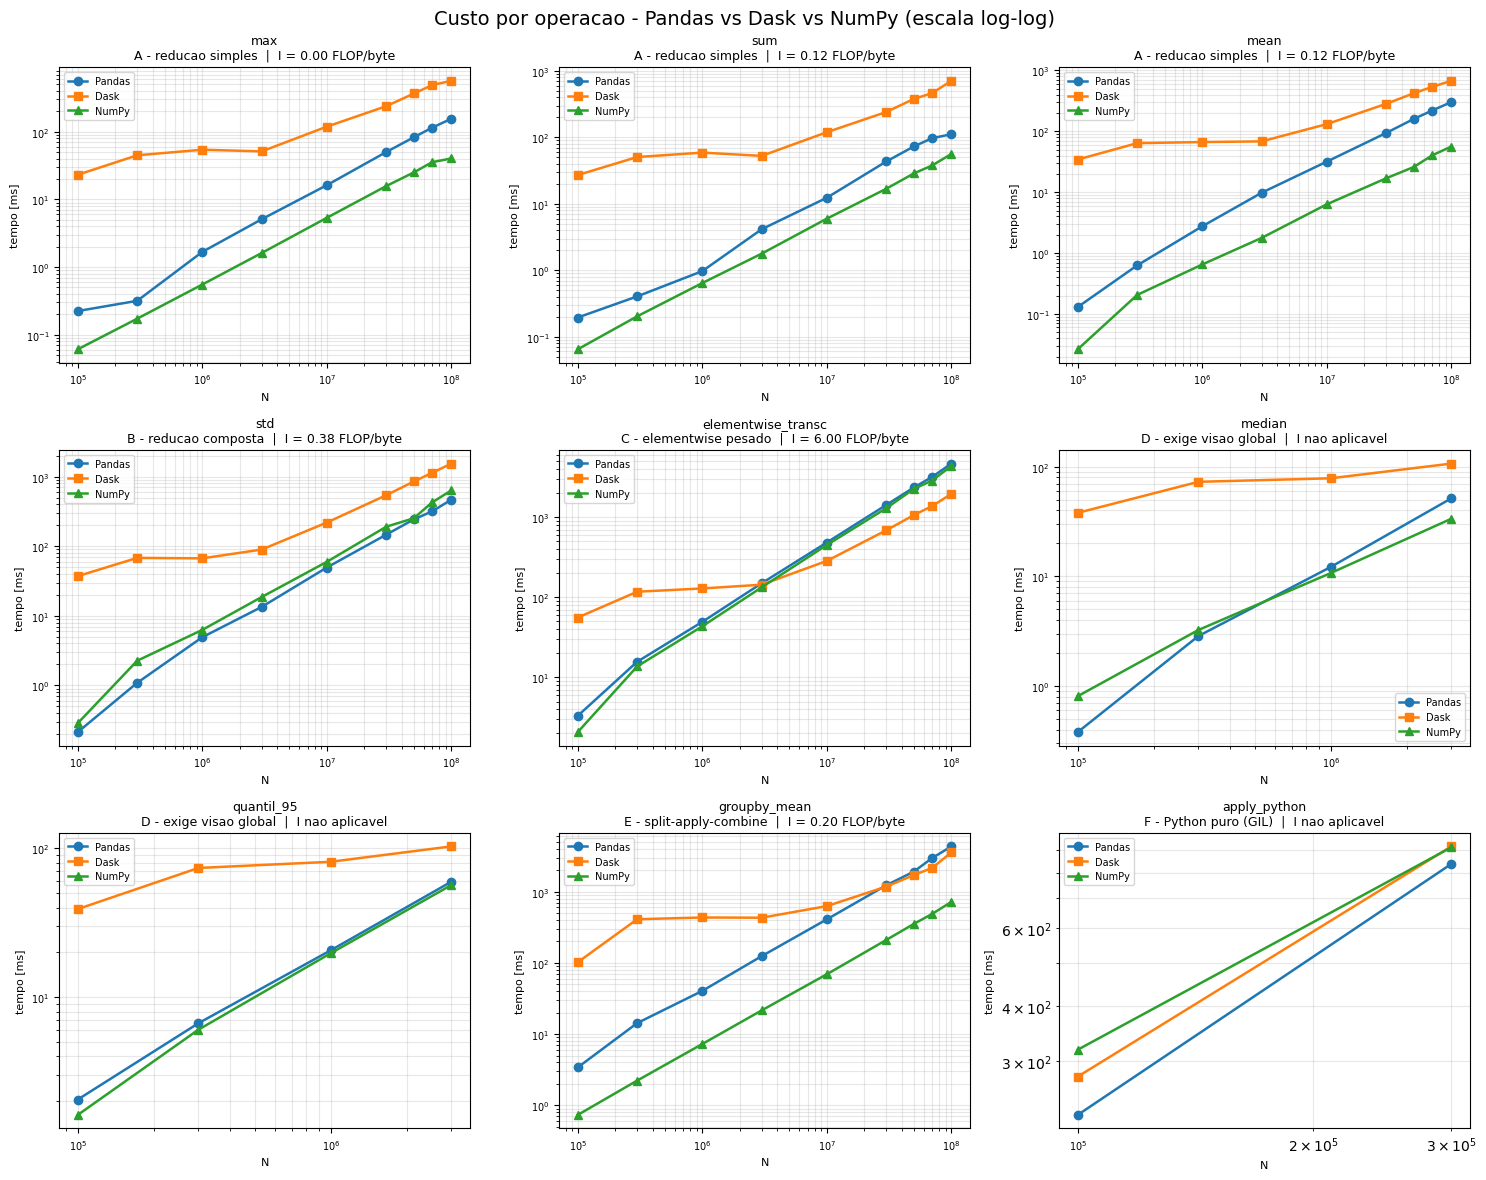

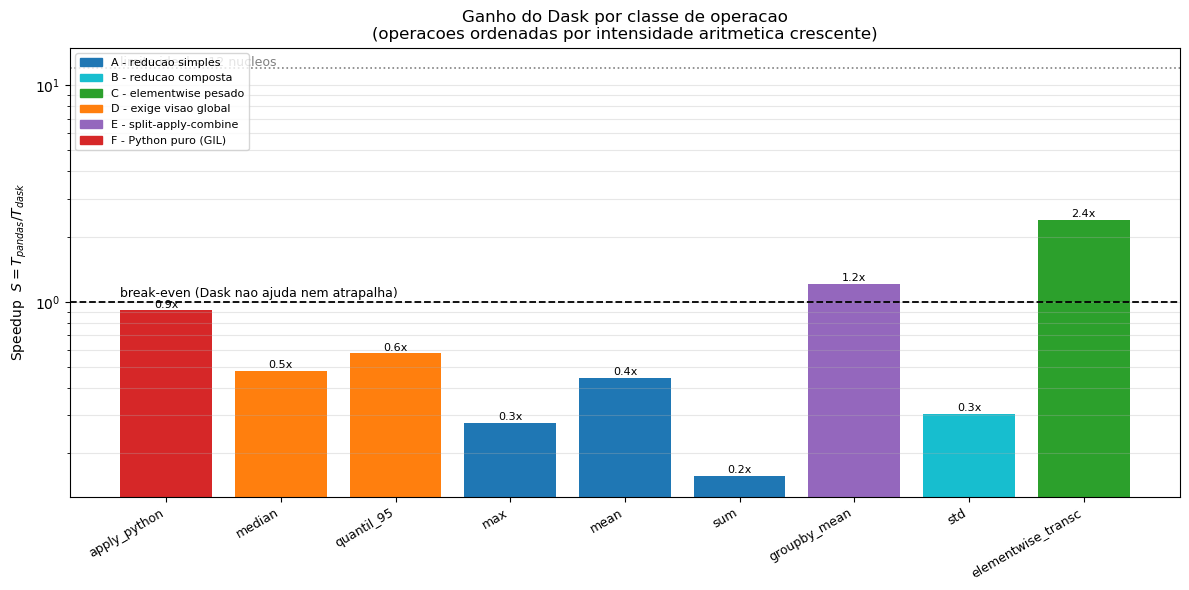

In [5]:
"""
Benchmark comparativo por CLASSE DE OPERACAO: Pandas vs Dask vs NumPy
======================================================================

Ideia central
-------------
O tamanho do dado nao e a variavel mais importante deste estudo. A variavel
mais importante e a INTENSIDADE ARITMETICA da operacao:

        I = operacoes de ponto flutuante / bytes lidos da memoria

Comparando I com o "machine balance" da maquina (FLOPS de pico dividido pela
largura de banda de pico) sabemos, ANTES de medir, se a operacao sera limitada
por memoria ou por CPU -- e portanto se vale a pena paralelizar.

Para o Snapdragon X Elite:
    FLOPS de pico ~ 12 nucleos x 3.8 GHz x 8 FLOP/ciclo  ~ 365 GFLOP/s
    Banda de pico ~ 135 GB/s (LPDDR5X unificada)
    machine balance ~ 2.7 FLOP/byte

Operacoes com I < 2.7  -> limitadas por memoria -> paralelismo ajuda pouco
Operacoes com I > 2.7  -> limitadas por CPU     -> paralelismo ajuda muito

Contexto de engenharia
----------------------
Os dados simulam uma campanha de ensaio de bancada:
    sinal    : leitura de acelerometro [g], com harmonica + ruido
    canal    : identificador do sensor (8 canais)
    reynolds : numero de Reynolds do escoamento em cada instante

Disciplina: Computacao de Alto Desempenho em Python
"""

import math
import platform
import time
import warnings

import dask
import dask.dataframe as dd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


# ============================================================================
# 1. PARAMETROS GLOBAIS
# ============================================================================

TAMANHOS = [100_000, 300_000, 1_000_000, 3_000_000, 10_000_000,30_000_000, 50_000_000, 70_000_000, 100_000_000]

N_BLOCOS_ALVO = 24        # multiplo do numero de nucleos (12), p/ balanceamento
N_CANAIS = 8              # numero de sensores no ensaio simulado
RUGOSIDADE_RELATIVA = 1e-4


# ============================================================================
# 2. GERACAO DOS DADOS
# ============================================================================

def gerar_dados_ensaio(n_amostras, semente=42):
    """Constroi o DataFrame que simula a campanha de ensaio."""
    gerador = np.random.default_rng(semente)

    tempo = np.arange(n_amostras, dtype=np.float64)
    sinal = (
        2.0 * np.sin(2.0 * np.pi * tempo / 1000.0)
        + gerador.normal(0.0, 0.3, size=n_amostras)
    )

    return pd.DataFrame({
        "sinal": sinal,
        "canal": gerador.integers(0, N_CANAIS, size=n_amostras),
        "reynolds": gerador.uniform(4.0e3, 1.0e6, size=n_amostras),
    })


# ============================================================================
# 3. A FUNCAO PYTHON PURA (caso do GIL)
# ============================================================================

def fator_atrito_haaland(reynolds):
    """
    Correlacao explicita de Haaland para o fator de atrito de Darcy em
    escoamento turbulento em duto:

        1/sqrt(f) = -1.8 * log10( (eps/D / 3.7)^1.11 + 6.9/Re )

    Escrita deliberadamente com o modulo 'math' (escalar), e nao com NumPy.
    Isso a torna codigo Python puro, que precisa segurar o GIL para executar.
    E exatamente o tipo de correlacao empirica que um engenheiro aplica
    linha a linha em uma planilha de ensaio.
    """
    termo = (RUGOSIDADE_RELATIVA / 3.7) ** 1.11 + 6.9 / reynolds
    return (-1.8 * math.log10(termo)) ** -2


# ============================================================================
# 4. REGISTRO DAS OPERACOES
# ============================================================================
# Cada entrada define a MESMA conta em tres bibliotecas.
# 'intensidade' e a estimativa de FLOP/byte usada na discussao teorica.
# 'n_maximo' limita operacoes muito caras, para o benchmark terminar.

OPERACOES = {
    "max": {
        "classe": "A - reducao simples",
        "intensidade": 0.0,
        "gargalo": "banda de memoria",
        "n_maximo": max(TAMANHOS),
        "pandas": lambda df: df["sinal"].max(),
        "dask":   lambda ddf: ddf["sinal"].max().compute(),
        "numpy":  lambda arr: arr["sinal"].max(),
    },
    "sum": {
        "classe": "A - reducao simples",
        "intensidade": 0.125,
        "gargalo": "banda de memoria",
        "n_maximo": max(TAMANHOS),
        "pandas": lambda df: df["sinal"].sum(),
        "dask":   lambda ddf: ddf["sinal"].sum().compute(),
        "numpy":  lambda arr: arr["sinal"].sum(),
    },
    "mean": {
        "classe": "A - reducao simples",
        "intensidade": 0.125,
        "gargalo": "banda de memoria",
        "n_maximo": max(TAMANHOS),
        "pandas": lambda df: df["sinal"].mean(),
        "dask":   lambda ddf: ddf["sinal"].mean().compute(),
        "numpy":  lambda arr: arr["sinal"].mean(),
    },
    "std": {
        "classe": "B - reducao composta",
        "intensidade": 0.375,
        "gargalo": "banda de memoria",
        "n_maximo": max(TAMANHOS),
        "pandas": lambda df: df["sinal"].std(),
        "dask":   lambda ddf: ddf["sinal"].std().compute(),
        "numpy":  lambda arr: arr["sinal"].std(ddof=1),
    },
    "elementwise_transc": {
        "classe": "C - elementwise pesado",
        "intensidade": 6.0,
        "gargalo": "CPU (unidades de ponto flutuante)",
        "n_maximo": max(TAMANHOS),
        "pandas": lambda df: (
            np.sin(df["sinal"]) ** 2 + np.sqrt(np.abs(df["sinal"]))
        ).mean(),
        "dask": lambda ddf: (
            np.sin(ddf["sinal"]) ** 2 + np.sqrt(np.abs(ddf["sinal"]))
        ).mean().compute(),
        "numpy": lambda arr: (
            np.sin(arr["sinal"]) ** 2 + np.sqrt(np.abs(arr["sinal"]))
        ).mean(),
    },
    "median": {
        "classe": "D - exige visao global",
        "intensidade": None,
        "gargalo": "movimentacao de dados / ordenacao",
        "n_maximo": 3_000_000,
        "pandas": lambda df: df["sinal"].median(),
        # ATENCAO: o quantile do Dask e APROXIMADO por padrao (t-digest).
        "dask":   lambda ddf: ddf["sinal"].quantile(0.5).compute(),
        "numpy":  lambda arr: np.median(arr["sinal"]),
    },
    "quantil_95": {
        "classe": "D - exige visao global",
        "intensidade": None,
        "gargalo": "movimentacao de dados / ordenacao",
        "n_maximo": 3_000_000,
        "pandas": lambda df: df["sinal"].quantile(0.95),
        "dask":   lambda ddf: ddf["sinal"].quantile(0.95).compute(),
        "numpy":  lambda arr: np.quantile(arr["sinal"], 0.95),
    },
    "groupby_mean": {
        "classe": "E - split-apply-combine",
        "intensidade": 0.2,
        "gargalo": "acesso aleatorio / cache",
        "n_maximo": max(TAMANHOS),
        "pandas": lambda df: df.groupby("canal")["sinal"].mean(),
        "dask":   lambda ddf: ddf.groupby("canal")["sinal"].mean().compute(),
        # Equivalente vetorizado em NumPy: soma por bin dividida pela contagem
        "numpy": lambda arr: (
            np.bincount(arr["canal"], weights=arr["sinal"], minlength=N_CANAIS)
            / np.bincount(arr["canal"], minlength=N_CANAIS)
        ),
    },
    "apply_python": {
        "classe": "F - Python puro (GIL)",
        "intensidade": None,
        "gargalo": "GIL / interpretador",
        "n_maximo": 300_000,      # 100x mais lento por elemento; precisa de teto
        "pandas": lambda df: df["reynolds"].apply(fator_atrito_haaland).mean(),
        "dask": lambda ddf: ddf["reynolds"].apply(
            fator_atrito_haaland, meta=("reynolds", "float64")
        ).mean().compute(),
        "numpy": lambda arr: np.mean(
            [fator_atrito_haaland(v) for v in arr["reynolds"]]
        ),
    },
}


# ============================================================================
# 5. MEDICAO
# ============================================================================

def medir_tempo(funcao, repeticoes=5, aquecimentos=1):
    """Devolve a mediana do tempo de execucao, em segundos."""
    for _ in range(aquecimentos):
        funcao()

    tempos = []
    for _ in range(repeticoes):
        inicio = time.perf_counter()
        funcao()
        tempos.append(time.perf_counter() - inicio)

    return float(np.median(tempos))


def escolher_repeticoes(n_amostras):
    """Menos repeticoes para casos caros, para o benchmark terminar em tempo."""
    if n_amostras <= 1_000_000:
        return 7
    if n_amostras <= 3_000_000:
        return 5
    return 3


def rodar_benchmark():
    resultados = []

    for n_amostras in TAMANHOS:
        print(f"\n{'='*68}\nN = {n_amostras:,} "
              f"({n_amostras * 8 / 1e6:.1f} MB por coluna)\n{'='*68}")

        df_pandas = gerar_dados_ensaio(n_amostras)
        n_particoes = max(1, min(N_BLOCOS_ALVO, n_amostras // 10_000))
        ddf = dd.from_pandas(df_pandas, npartitions=n_particoes)

        # Views NumPy das colunas: sem copia, para ser uma comparacao justa
        arrays_numpy = {
            "sinal": df_pandas["sinal"].to_numpy(),
            "canal": df_pandas["canal"].to_numpy(),
            "reynolds": df_pandas["reynolds"].to_numpy(),
        }

        repeticoes = escolher_repeticoes(n_amostras)

        for nome, definicao in OPERACOES.items():
            if n_amostras > definicao["n_maximo"]:
                continue

            print(f"  {nome:<20}", end="", flush=True)

            t_pandas = medir_tempo(
                lambda: definicao["pandas"](df_pandas), repeticoes
            )
            t_dask = medir_tempo(
                lambda: definicao["dask"](ddf), repeticoes
            )
            t_numpy = medir_tempo(
                lambda: definicao["numpy"](arrays_numpy), repeticoes
            )

            resultados.append({
                "operacao": nome,
                "classe": definicao["classe"],
                "intensidade": definicao["intensidade"],
                "gargalo": definicao["gargalo"],
                "n_amostras": n_amostras,
                "n_particoes": n_particoes,
                "t_pandas": t_pandas,
                "t_dask": t_dask,
                "t_numpy": t_numpy,
            })

            print(f"pandas {t_pandas*1e3:8.2f} ms | "
                  f"dask {t_dask*1e3:8.2f} ms | "
                  f"numpy {t_numpy*1e3:8.2f} ms | "
                  f"S = {t_pandas/t_dask:5.2f}x")

        del df_pandas, ddf, arrays_numpy

    tabela = pd.DataFrame(resultados)
    tabela["speedup_dask_pandas"] = tabela["t_pandas"] / tabela["t_dask"]
    tabela["speedup_dask_numpy"] = tabela["t_numpy"] / tabela["t_dask"]
    return tabela


# ============================================================================
# 6. GRAFICOS
# ============================================================================

def plotar_grade_de_tempos(tabela, arquivo="grade_operacoes.png"):
    """Um subplot por operacao: tempo x N em escala log-log."""
    nomes = list(OPERACOES.keys())
    n_linhas, n_colunas = 3, 3

    figura, eixos = plt.subplots(n_linhas, n_colunas, figsize=(15, 12))
    eixos = eixos.ravel()

    for indice, nome in enumerate(nomes):
        eixo = eixos[indice]
        dados = tabela[tabela["operacao"] == nome]

        eixo.loglog(dados["n_amostras"], dados["t_pandas"] * 1e3,
                    "o-", label="Pandas", linewidth=1.8)
        eixo.loglog(dados["n_amostras"], dados["t_dask"] * 1e3,
                    "s-", label="Dask", linewidth=1.8)
        eixo.loglog(dados["n_amostras"], dados["t_numpy"] * 1e3,
                    "^-", label="NumPy", linewidth=1.8)

        definicao = OPERACOES[nome]
        intensidade = definicao["intensidade"]
        texto_i = (f"I = {intensidade:.2f} FLOP/byte"
                   if intensidade is not None else "I nao aplicavel")

        eixo.set_title(f"{nome}\n{definicao['classe']}  |  {texto_i}",
                       fontsize=9)
        eixo.set_xlabel("N", fontsize=8)
        eixo.set_ylabel("tempo [ms]", fontsize=8)
        eixo.grid(True, which="both", alpha=0.3)
        eixo.legend(fontsize=7)
        eixo.tick_params(labelsize=7)

    for indice in range(len(nomes), len(eixos)):
        eixos[indice].axis("off")

    figura.suptitle(
        "Custo por operacao - Pandas vs Dask vs NumPy (escala log-log)",
        fontsize=14
    )
    figura.tight_layout()
    figura.savefig(arquivo, dpi=150)
    print(f"\nGrafico salvo: {arquivo}")


def plotar_speedup_por_operacao(tabela, arquivo="speedup_por_operacao.png"):
    """
    Grafico-sintese: speedup do Dask sobre o Pandas, no maior N testado de
    cada operacao, ordenado por intensidade aritmetica.

    E este grafico que revela o padrao central do estudo.
    """
    # Para cada operacao, pega a linha do maior N disponivel
    indices = tabela.groupby("operacao")["n_amostras"].idxmax()
    resumo = tabela.loc[indices].copy()

    # Ordena por intensidade (as sem intensidade definida vao para o fim)
    resumo["ordem"] = resumo["intensidade"].fillna(-1.0)
    resumo = resumo.sort_values("ordem")

    cores_por_classe = {
        "A - reducao simples": "tab:blue",
        "B - reducao composta": "tab:cyan",
        "C - elementwise pesado": "tab:green",
        "D - exige visao global": "tab:orange",
        "E - split-apply-combine": "tab:purple",
        "F - Python puro (GIL)": "tab:red",
    }
    cores = [cores_por_classe[c] for c in resumo["classe"]]

    figura, eixo = plt.subplots(figsize=(12, 6))
    barras = eixo.bar(resumo["operacao"], resumo["speedup_dask_pandas"],
                      color=cores)

    eixo.axhline(1.0, color="black", linestyle="--", linewidth=1.3)
    eixo.text(-0.4, 1.05, "break-even (Dask nao ajuda nem atrapalha)",
              fontsize=9)
    eixo.axhline(12.0, color="gray", linestyle=":", linewidth=1.2)
    eixo.text(-0.4, 12.3, "limite ideal = 12 nucleos", fontsize=9,
              color="gray")

    for barra, valor in zip(barras, resumo["speedup_dask_pandas"]):
        eixo.text(barra.get_x() + barra.get_width() / 2,
                  barra.get_height() * 1.03,
                  f"{valor:.1f}x", ha="center", fontsize=8)

    eixo.set_ylabel("Speedup  $S = T_{pandas} / T_{dask}$")
    eixo.set_title(
        "Ganho do Dask por classe de operacao\n"
        "(operacoes ordenadas por intensidade aritmetica crescente)",
        fontsize=12
    )
    eixo.set_yscale("log")
    eixo.grid(True, axis="y", which="both", alpha=0.3)
    plt.setp(eixo.get_xticklabels(), rotation=30, ha="right", fontsize=9)

    # Legenda manual por classe
    from matplotlib.patches import Patch
    eixo.legend(
        handles=[Patch(color=cor, label=classe)
                 for classe, cor in cores_por_classe.items()],
        fontsize=8, loc="upper left"
    )

    figura.tight_layout()
    figura.savefig(arquivo, dpi=150)
    print(f"Grafico salvo: {arquivo}")


# ============================================================================
# 7. VERIFICACAO DA APROXIMACAO DA MEDIANA
# ============================================================================

def verificar_mediana_aproximada(n_amostras=3_000_000):
    """
    Demonstra que o quantile do Dask e APROXIMADO por padrao.

    Este e um resultado de CORRETUDE, nao de desempenho, e costuma passar
    despercebido. Em engenharia, usar um percentil aproximado como criterio
    de projeto pode ser inaceitavel.
    """
    df = gerar_dados_ensaio(n_amostras)
    ddf = dd.from_pandas(df, npartitions=N_BLOCOS_ALVO)

    print("\n" + "=" * 68)
    print("VERIFICACAO DE CORRETUDE - mediana e percentil 95")
    print("=" * 68)

    for quantil in [0.5, 0.95, 0.99]:
        exato = df["sinal"].quantile(quantil)
        aproximado = ddf["sinal"].quantile(quantil).compute()
        erro_relativo = abs(aproximado - exato) / abs(exato)

        print(f"q = {quantil:.2f} | pandas (exato) = {exato: .8f} | "
              f"dask = {aproximado: .8f} | erro rel. = {erro_relativo:.2e}")


# ============================================================================
# 8. EXECUCAO
# ============================================================================

if __name__ == "__main__":
    print("=" * 68)
    print(f"Plataforma  : {platform.platform()}")
    print(f"Arquitetura : {platform.machine()}   (esperado ARM64)")
    print(f"NumPy {np.__version__} | Pandas {pd.__version__} | "
          f"Dask {dask.__version__}")
    print("=" * 68)

    tabela_resultados = rodar_benchmark()
    tabela_resultados.to_csv("resultados_por_operacao.csv", index=False)

    plotar_grade_de_tempos(tabela_resultados)
    plotar_speedup_por_operacao(tabela_resultados)

    verificar_mediana_aproximada()

    plt.show()